In [1]:
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = Path().resolve()

In [3]:
contig_info = pd.read_csv(data / "contig_info.csv")
mash = pd.read_table(data / "mash/mash_edges.tsv", sep="\t", header=None, names=["plasmid_1", "plasmid_2", "distance", "p_val", "shared_hashes"])
pling = pd.read_table(data / "pling/containment/all_pairs_containment_distance.tsv", sep="\t")

In [4]:
contig_size = dict(zip(contig_info["accession"], contig_info["size"]))

In [5]:
mash["plasmid_1"] = mash["plasmid_1"].apply(lambda x: Path(x).stem)
mash["plasmid_2"] = mash["plasmid_2"].apply(lambda x: Path(x).stem)
mash["plasmid_size_difference"] = mash.apply(lambda x: max(contig_size[x["plasmid_1"]], contig_size[x["plasmid_2"]]) - min(contig_size[x["plasmid_1"]], contig_size[x["plasmid_2"]]),axis=1)

In [6]:
pling["plasmid_size_ratio"] = pling.apply(lambda x: min(contig_size[x["plasmid_1"]], contig_size[x["plasmid_2"]]) / max(contig_size[x["plasmid_1"]], contig_size[x["plasmid_2"]]), axis=1)

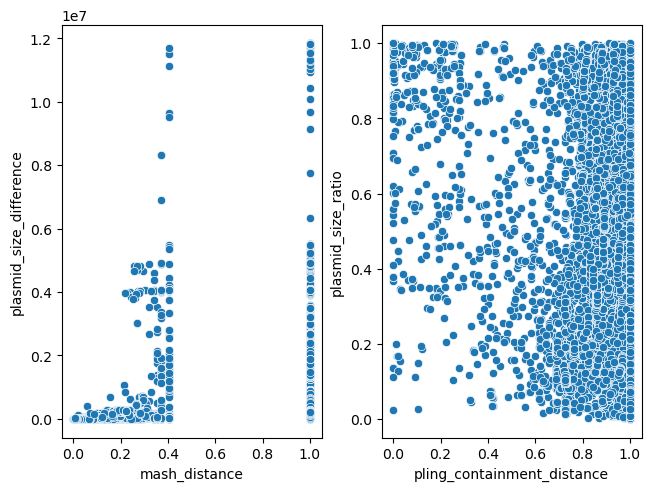

In [8]:
fig = plt.figure(constrained_layout=True)
grid = fig.add_gridspec(1,2)
a = fig.add_subplot(grid[0,0])
b = fig.add_subplot(grid[0,1])
sns.scatterplot(mash, x="distance", y="plasmid_size_difference", ax=a)
sns.scatterplot(pling, x="distance", y="plasmid_size_ratio", ax=b)
a.set_xlabel("mash_distance")
b.set_xlabel("pling_containment_distance")
plt.savefig(data / 'size-vs-distances.pdf', bbox_inches='tight')